**E-commerce Customer Segmentation and Prediction**

Importing required libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score, recall_score, f1_score

import joblib

Loading the data and check basic information

In [ ]:
df = pd.read_csv('/content/data.csv', encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
df.shape

(541909, 8)

**Data Cleaning**

In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df[df['UnitPrice'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,12/8/2011 13:58,0.0,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,12/8/2011 13:58,0.0,NaN,United Kingdom
538554,581408,85175,NaN,20,12/8/2011 14:06,0.0,NaN,United Kingdom


In [ ]:
df[df['Quantity'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


In [ ]:
df[df['InvoiceNo'].astype(str).str.startswith('C')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


The Invoice Numbers staring with 'C' and negative values in Quantity stand for returned or cancelled order.

Including them would distort frequency and monetary metrics used for customer segmentation.

Drop the null and returned values.

In [ ]:
df = df.dropna(subset=['CustomerID'])
df = df[df['UnitPrice'] > 0]
df = df[df['Quantity'] > 0]
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [ ]:
df.shape

(397884, 8)

Cross check the cleaned dataset

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(0)

In [ ]:
(df['Quantity'] <= 0).sum()

np.int64(0)

In [ ]:
df['CustomerID'].isnull().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


In [ ]:
#Changing data types CustomerId to int and InvoiceDate to Datatime
df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
#Checking the data types
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,int64
Country,object


**Feature Engineering**

In [ ]:
#Creating a new column called TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

#Setting the snapshot date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

**Visualization of the cleaned dataset**

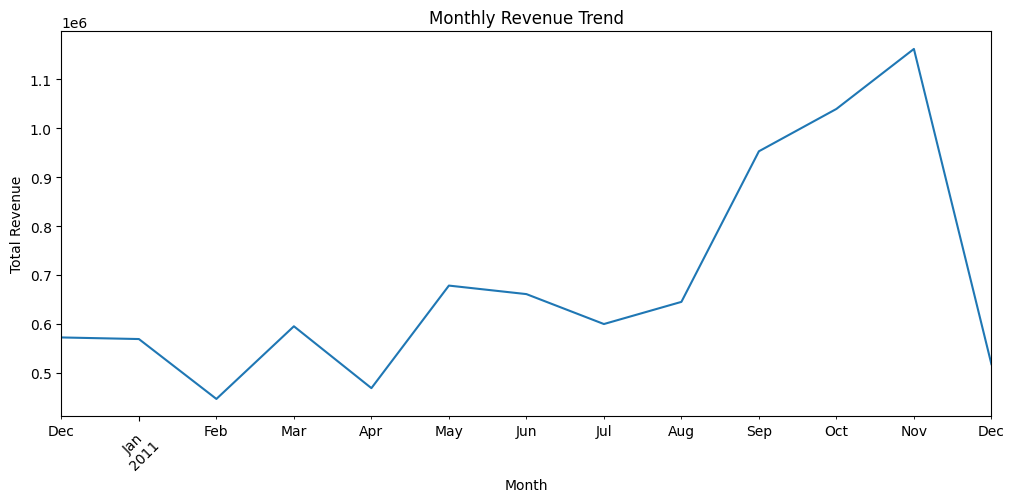

In [ ]:
# Extract year-month
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

#Monthly Revenue Trend
monthly_sales = df.groupby('YearMonth')['TotalPrice'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

The monthly revenue trend shows seasonality patterns and peak sales periods.

/tmp/ipython-input-3631833013.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='magma')


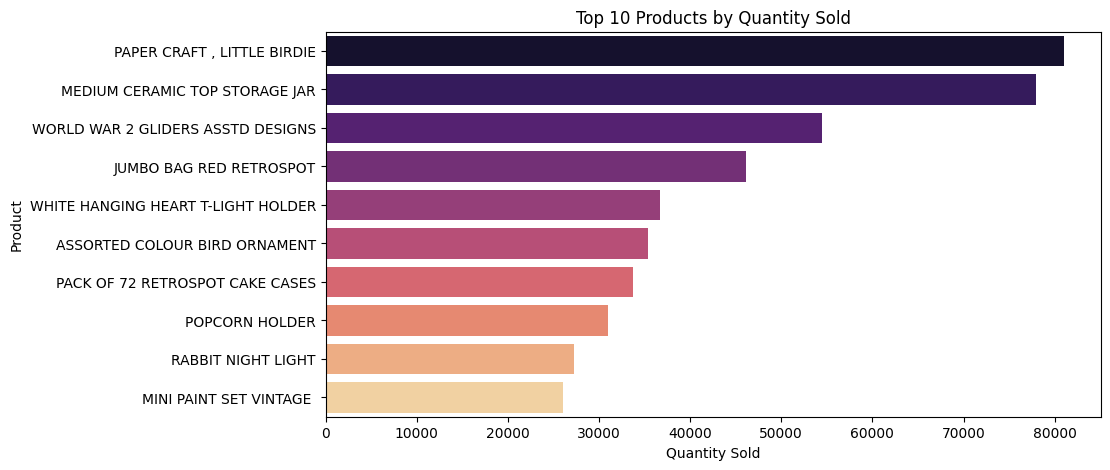

In [ ]:
#Top 10 Products by Quantity Sold
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_products.values, y=top_products.index, palette='magma')
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.show()

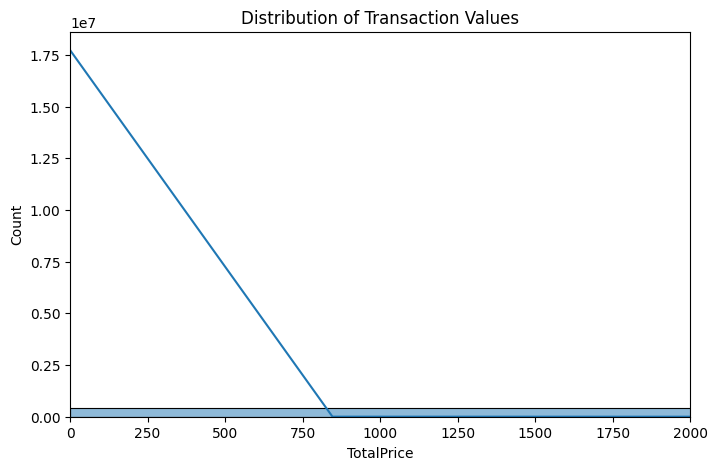

In [ ]:
#Distribution of Transaction Values
plt.figure(figsize=(8,5))
sns.histplot(df['TotalPrice'], bins=50, kde=True)
plt.title("Distribution of Transaction Values")
plt.xlim(0, 2000)  # limit to visualize better
plt.show()

Transaction values are highly right-skewed, with most purchases being low value and a few high-value transactions.

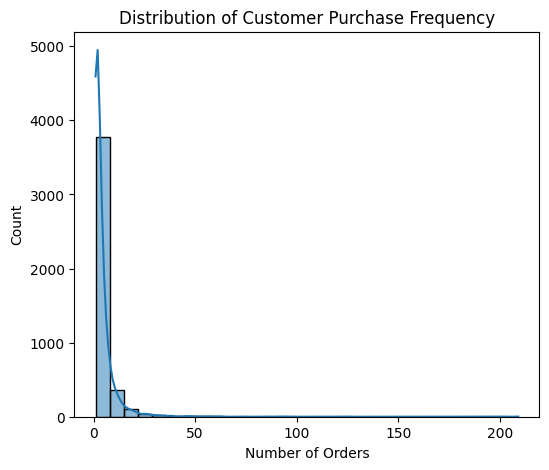

In [ ]:
#Distribution of Customer Purchase Frequency
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()

plt.figure(figsize=(6,5))
sns.histplot(customer_orders, bins=30, kde=True)
plt.title("Distribution of Customer Purchase Frequency")
plt.xlabel("Number of Orders")
plt.show()

The distribution of customer purchase frequency is highly right-skewed. Most customers place only a small number of orders, while a small group of customers make frequent purchases. This indicates the presence of a core group of loyal or high-value customers

**Feature Engineering**

In [ ]:
#Create the rfm dataset
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [ ]:
#Checking the statistics of the new dataset
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


**Plots for the RFM dataset to check the distribution, outliers, and correlation**

1. Distribution Plots of Raw RFM Features

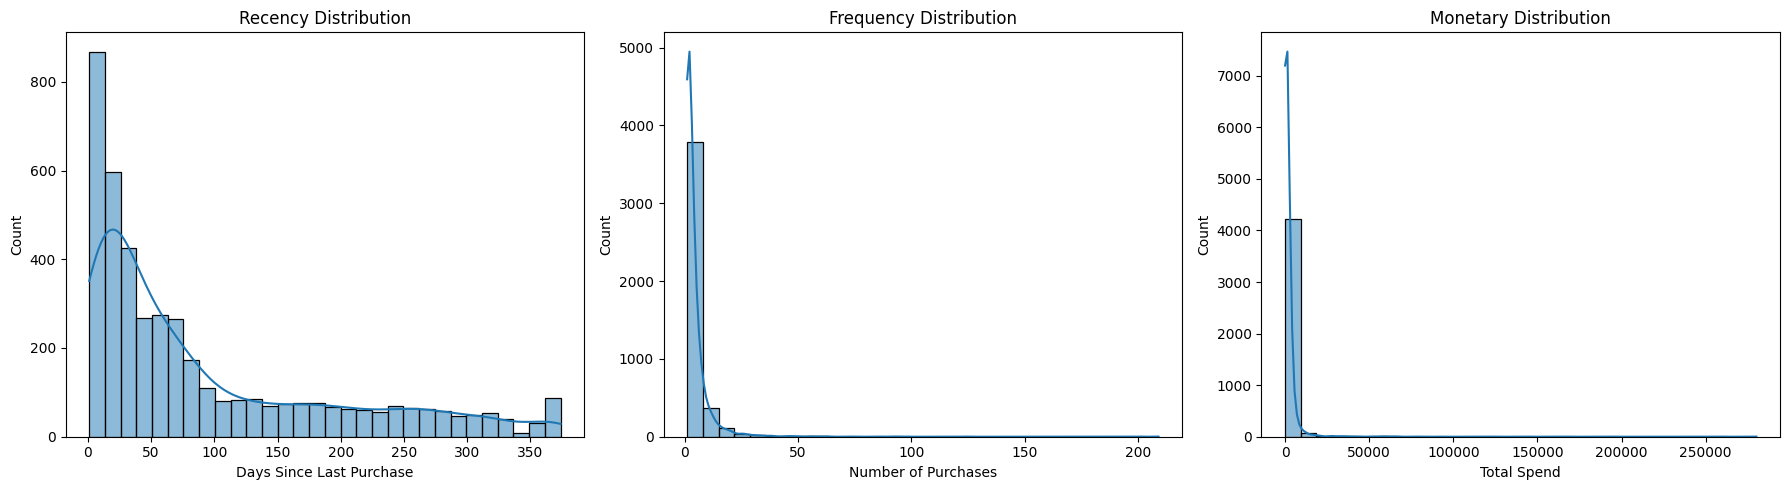

In [ ]:
#Histograms for the ditribution
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.histplot(rfm['Recency'], bins=30, kde=True)
plt.title('Recency Distribution')
plt.xlabel('Days Since Last Purchase')

plt.subplot(1,3,2)
sns.histplot(rfm['Frequency'], bins=30, kde=True)
plt.title('Frequency Distribution')
plt.xlabel('Number of Purchases')

plt.subplot(1,3,3)
sns.histplot(rfm['Monetary'], bins=30, kde=True)
plt.title('Monetary Distribution')
plt.xlabel('Total Spend')

plt.tight_layout()
plt.show()

The histograms show that these features are highly right-skewed, meaning most customers have low recency values (recent purchases), low purchase frequencies, and lower monetary spend, while a few customers make very frequent purchases or spend significantly more.

2. Boxplot for Detecting Outliers

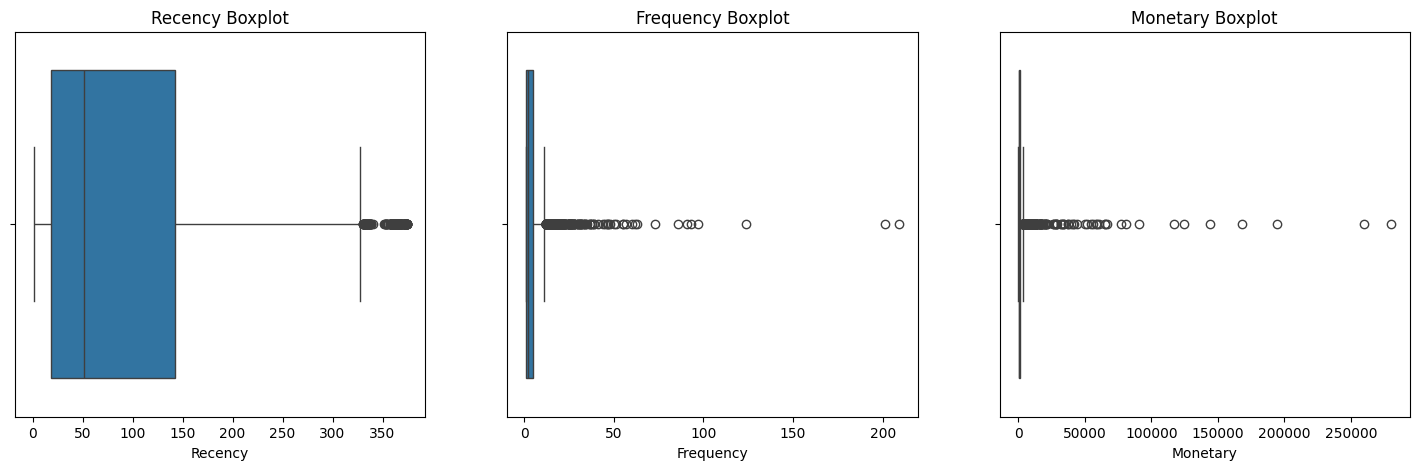

In [ ]:
#Boxplot to check for outliers
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.boxplot(x=rfm['Recency'])
plt.title('Recency Boxplot')

plt.subplot(1,3,2)
sns.boxplot(x=rfm['Frequency'])
plt.title('Frequency Boxplot')

plt.subplot(1,3,3)
sns.boxplot(x=rfm['Monetary'])
plt.title('Monetary Boxplot')


plt.show()

3. Pairplot of RFM Features

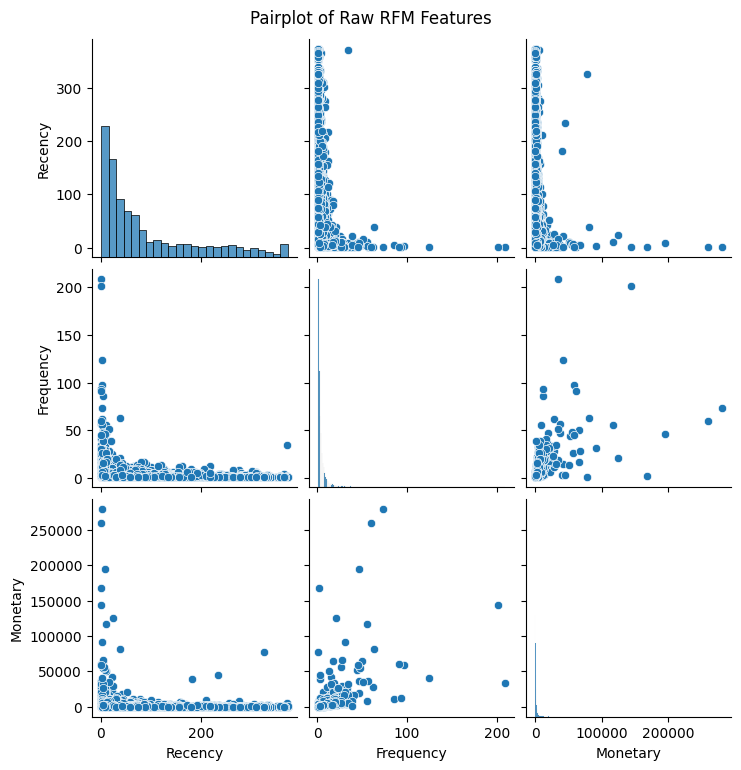

In [ ]:
#Pairplot of RFM Features
sns.pairplot(rfm[['Recency','Frequency','Monetary']])
plt.suptitle('Pairplot of Raw RFM Features', y=1.02)
plt.show()


4. Correlation Heatmap of RFM Features

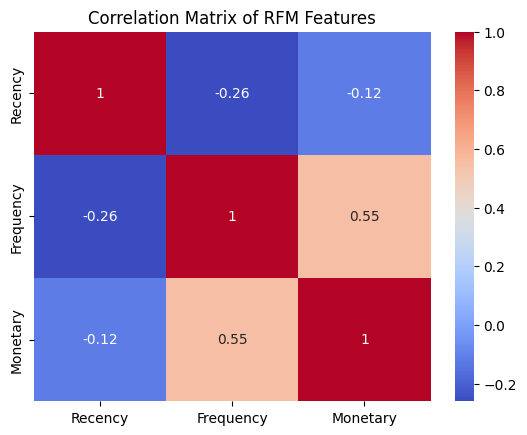

In [ ]:
#Correlation Heatmap of RFM Features
sns.heatmap(rfm[['Recency','Frequency','Monetary']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of RFM Features')
plt.show()

**Log Transformation & Scaling**

The histograms show that these features are highly right-skewed, meaning most customers have low recency values (recent purchases), low purchase frequencies, and lower monetary spend, while a few customers make very frequent purchases or spend significantly more.

In [ ]:
# Make a copy to keep original RFM intact
rfm_log = rfm.copy()

# Apply log1p (log(1 + x)) to reduce skewness
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

rfm_log.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,5.789960,0.693147,11.253955
12347,1.098612,2.079442,8.368925
12348,4.330733,1.609438,7.494564
12349,2.995732,0.693147,7.472245
12350,5.739793,0.693147,5.815324


In [ ]:
#Scaling the data

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

**Clustering Algorithms**

1. K-means Clustering

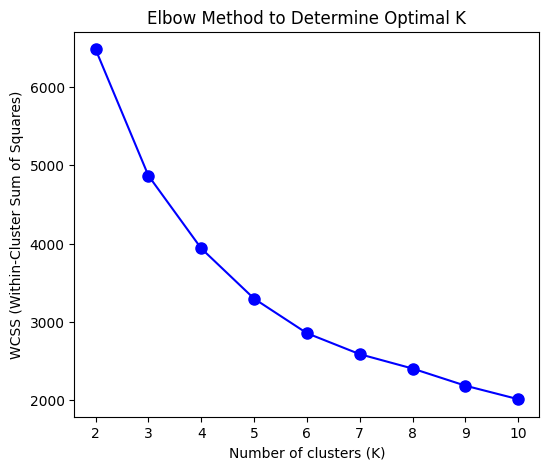

In [ ]:
#Using elbow method to set the number of clusters
wcss = []
K_range = range(2, 11)  # try 2 to 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,5))
plt.plot(K_range, wcss, 'bo-', markersize=8)
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Elbow Method to Determine Optimal K')
plt.show()

The optimal number of clusters is set to '4'

In [ ]:
#Applying the k-means algorithm
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(rfm_scaled)

# Silhouette Score
silhouette_kmeans = silhouette_score(rfm_scaled, kmeans_labels)
print("Silhouette Score - KMeans:", round(silhouette_kmeans, 3))

# Add to RFM for profiling
rfm['KMeans_Cluster'] = kmeans_labels

Silhouette Score - KMeans: 0.337


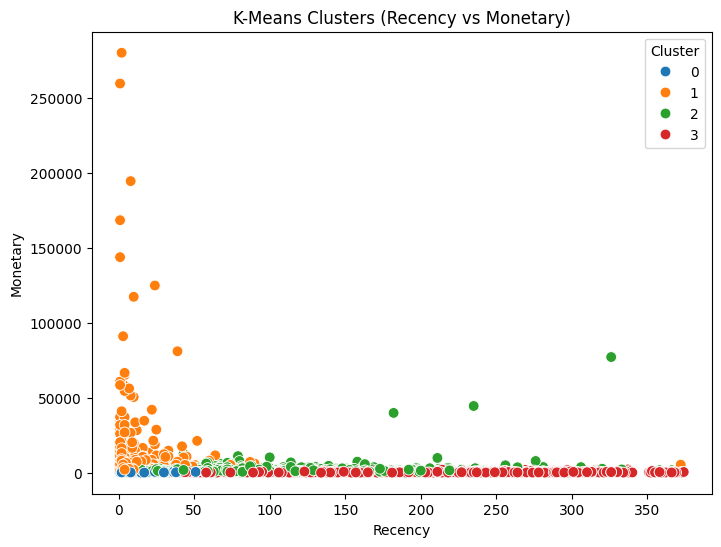

In [ ]:
#Scatter plot for the K-means cluster
plt.figure(figsize=(8,6))
sns.scatterplot(x='Recency', y='Monetary', hue='KMeans_Cluster',
                data=rfm, palette='tab10', s=60)
plt.title('K-Means Clusters (Recency vs Monetary)')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.legend(title='Cluster')
plt.show()

2. Hierarchical Clustering

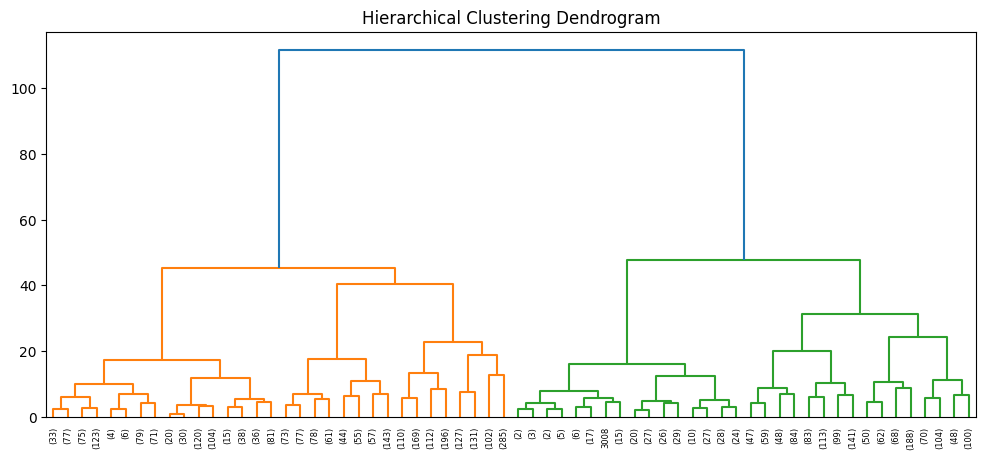

Silhouette Score - Hierarchical: 0.242


In [ ]:
# Linkage matrix
linkage_matrix = linkage(rfm_scaled, method='ward')

# Optional: Plot dendrogram (for small datasets)
plt.figure(figsize=(12,5))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

# Cut dendrogram to form 4 clusters
hier_labels = fcluster(linkage_matrix, t=4, criterion='maxclust')

# Silhouette Score
silhouette_hier = silhouette_score(rfm_scaled, hier_labels)
print("Silhouette Score - Hierarchical:", round(silhouette_hier, 3))

rfm['Hier_Cluster'] = hier_labels

3. DBSCAN

In [ ]:
# DBSCAN
dbscan = DBSCAN(eps=2, min_samples=10)
dbscan_labels = dbscan.fit_predict(rfm_scaled)

# Check unique labels
print(np.unique(dbscan_labels))

mask = dbscan_labels != -1  # ignore noise
if len(np.unique(dbscan_labels[mask])) > 1:
    silhouette_dbscan = silhouette_score(rfm_scaled[mask], dbscan_labels[mask])
else:
    silhouette_dbscan = -1

rfm['DBSCAN_Cluster'] = dbscan_labels

# Unique cluster labels
print("Unique DBSCAN labels:", np.unique(dbscan_labels))

# Cluster sizes (including noise)
print("DBSCAN cluster counts:\n", pd.Series(dbscan_labels).value_counts())

if silhouette_dbscan != -1:
    print("Silhouette Score - DBSCAN:", round(silhouette_dbscan,3))
else:
    print("Silhouette Score - DBSCAN: Not computable (too few clusters)")

[-1  0]
Unique DBSCAN labels: [-1  0]
DBSCAN cluster counts:
  0    4337
-1       1
Name: count, dtype: int64
Silhouette Score - DBSCAN: Not computable (too few clusters)


Comparing the silhoette score of all the models to select the best model

In [ ]:
print("K-Means Silhouette:", round(silhouette_kmeans,3))
print("Hierarchical Silhouette:", round(silhouette_hier,3))
print("DBSCAN Silhouette:", silhouette_dbscan)

print(" \n")
final_cluster = 'KMeans_Cluster'

cluster_summary = rfm.groupby(final_cluster).agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':['mean','count']
}).round(1)

print(cluster_summary)

K-Means Silhouette: 0.337
Hierarchical Silhouette: 0.242
DBSCAN Silhouette: -1
 

               Recency Frequency Monetary      
                  mean      mean     mean count
KMeans_Cluster                                 
0                 18.1       2.1    551.8   837
1                 12.1      13.7   8074.3   716
2                 71.1       4.1   1802.8  1173
3                182.5       1.3    343.5  1612


**Labels for the clusters**

0 - *New Customers OR
Recent Low-Engagement Customers*

Very recent, low frequency & low monetary

1 - *High-Value VIP Customers*

Very recent, very high frequency & very high monetary

2 - *Loyal Mid-Value Customers*

Moderate recency, moderate frequency & monetary

3 - *At-Risk / Lost Customers
Dormant*

Very old recency, very low frequency & low monetary


**Prediction Algorithms**

In [ ]:
#Check the rfm model
rfm.head()

,Recency,Frequency,Monetary,KMeans_Cluster,Hier_Cluster,DBSCAN_Cluster
CustomerID,,,,,,
12346,326,1,77183.60,2,2,0
12347,2,7,4310.00,1,4,0
12348,75,4,1797.24,2,2,0
12349,19,1,1757.55,0,4,0
12350,310,1,334.40,3,1,0


Need to remove the segmentations created by hierarchical and DBSCAN algorithms as they are not used.

In [ ]:
rfm_model = rfm[['Recency', 'Frequency', 'Monetary', 'KMeans_Cluster']].copy()
rfm_model.head()

,Recency,Frequency,Monetary,KMeans_Cluster
CustomerID,,,,
12346,326,1,77183.60,2
12347,2,7,4310.00,1
12348,75,4,1797.24,2
12349,19,1,1757.55,0
12350,310,1,334.40,3


In [ ]:
#checking the distribution
rfm_model['KMeans_Cluster'].value_counts()

,count
KMeans_Cluster,
3,1612
2,1173
0,837
1,716


In [ ]:
#Preparing the dataset
X = rfm_model[['Recency', 'Frequency', 'Monetary']]

#KMeans_Cluster column becomes the target column
y = rfm_model['KMeans_Cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Applying predictive algoeithms to choose the best model**

In [ ]:
# Scale features for Logistic Regression ans SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

1. Logistic Regression

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy: 0.9262672811059908
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92       167
           1       0.97      0.95      0.96       149
           2       0.92      0.85      0.88       230
           3       0.93      0.96      0.95       322

    accuracy                           0.93       868
   macro avg       0.93      0.93      0.93       868
weighted avg       0.93      0.93      0.93       868



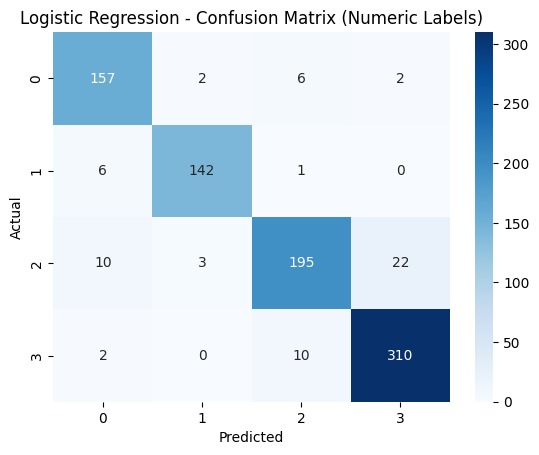

In [ ]:
# Logistic Regression
logreg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
logreg.fit(X_train_scaled, y_train)
y_pred_log = logreg.predict(X_test_scaled)

# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))

# Confusion Matrix with numeric labels
cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix (Numeric Labels)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


Parameters used


*   multi_class='multinomial'

    Tells the model that your target has more than 2 classes.

    Without it, LogisticRegression defaults to 'auto', which can still work, but for true multi-class problems, 'multinomial' usually gives better probability estimates.
*   solver='lbfgs'

    The optimization algorithm to fit the model.

    'lbfgs' works well for multinomial logistic regression and is good for medium to large datasets.


*   max_iter=1000

    Maximum number of iterations for the solver to converge.

    Sometimes the default 100 isn’t enough for bigger datasets, so setting 1000 ensures the model converges without warnings.





2. Decision Tree

Decision Tree Accuracy: 0.9585253456221198
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.96       167
           1       0.94      0.95      0.95       149
           2       0.94      0.93      0.94       230
           3       0.98      0.98      0.98       322

    accuracy                           0.96       868
   macro avg       0.96      0.96      0.96       868
weighted avg       0.96      0.96      0.96       868



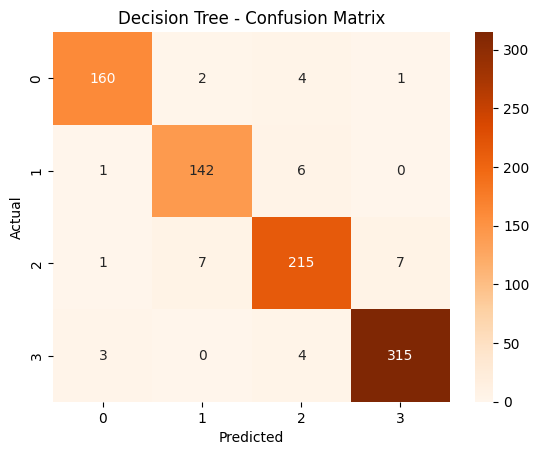

In [ ]:
# Decision Tree
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)
y_pred_dt = dtree.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('Decision Tree - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

3. Random Forest Classifier

Random Forest Accuracy: 0.9838709677419355
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       167
           1       0.98      1.00      0.99       149
           2       0.97      0.98      0.98       230
           3       0.99      0.98      0.99       322

    accuracy                           0.98       868
   macro avg       0.98      0.99      0.98       868
weighted avg       0.98      0.98      0.98       868



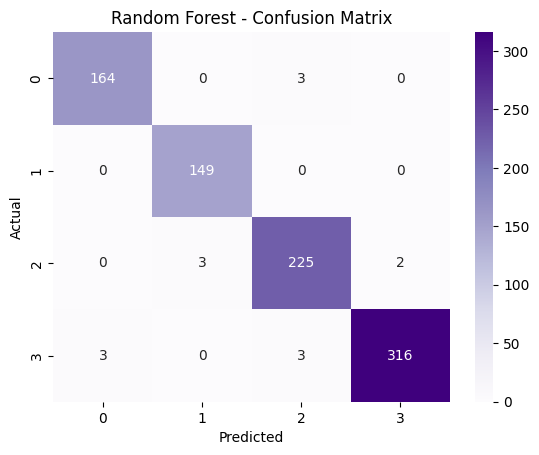

In [ ]:
#Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

4. Support Vector Machine (SVM)

In [ ]:
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best Accuracy: 0.9585014409221901


SVM Accuracy: 0.9573732718894009
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95       167
           1       0.99      0.98      0.98       149
           2       0.94      0.92      0.93       230
           3       0.96      0.98      0.97       322

    accuracy                           0.96       868
   macro avg       0.96      0.96      0.96       868
weighted avg       0.96      0.96      0.96       868



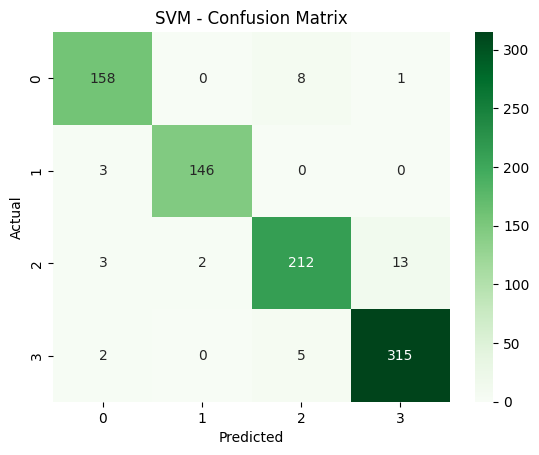

In [ ]:
# Support Vector Machine
svm_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('SVM - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Comparing the models to select the best model

                     Precision  Recall  F1-score  Accuracy
Logistic Regression      0.926   0.926     0.926     0.926
Decision Tree            0.959   0.959     0.959     0.959
Random Forest            0.984   0.984     0.984     0.984
SVM                      0.957   0.957     0.957     0.957


/tmp/ipython-input-862182074.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metrics_df['Accuracy'], palette='viridis')


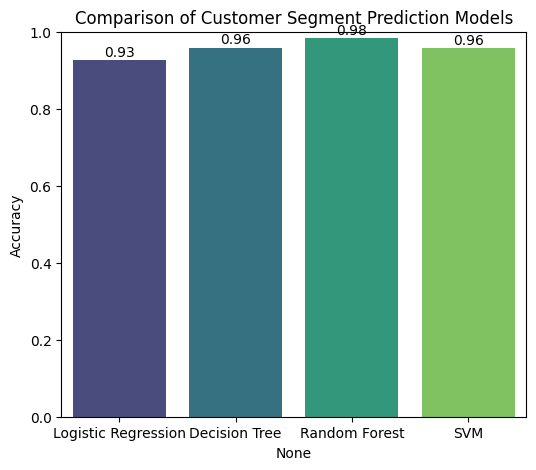

Best Model based on Accuracy: Random Forest


In [ ]:
# -------------------------------
# 1️⃣ Calculate metrics for each model
# -------------------------------
metrics_dict = {}

# Logistic Regression
metrics_dict['Logistic Regression'] = {
    'Precision': precision_score(y_test, y_pred_log, average='weighted'),
    'Recall': recall_score(y_test, y_pred_log, average='weighted'),
    'F1-score': f1_score(y_test, y_pred_log, average='weighted'),
    'Accuracy': accuracy_score(y_test, y_pred_log)
}

# Decision Tree
metrics_dict['Decision Tree'] = {
    'Precision': precision_score(y_test, y_pred_dt, average='weighted'),
    'Recall': recall_score(y_test, y_pred_dt, average='weighted'),
    'F1-score': f1_score(y_test, y_pred_dt, average='weighted'),
    'Accuracy': accuracy_score(y_test, y_pred_dt)
}

# Random Forest
metrics_dict['Random Forest'] = {
    'Precision': precision_score(y_test, y_pred_rf, average='weighted'),
    'Recall': recall_score(y_test, y_pred_rf, average='weighted'),
    'F1-score': f1_score(y_test, y_pred_rf, average='weighted'),
    'Accuracy': accuracy_score(y_test, y_pred_rf)
}
# SVM
metrics_dict['SVM'] = {
    'Precision': precision_score(y_test, y_pred_svm, average='weighted'),
    'Recall': recall_score(y_test, y_pred_svm, average='weighted'),
    'F1-score': f1_score(y_test, y_pred_svm, average='weighted'),
    'Accuracy': accuracy_score(y_test, y_pred_svm)
}

# Convert to DataFrame for display
metrics_df = pd.DataFrame(metrics_dict).T.round(3)
print(metrics_df)

# -------------------------------
# 2️⃣ Plot Accuracy Bar Chart
# -------------------------------
plt.figure(figsize=(6,5))
sns.barplot(x=metrics_df.index, y=metrics_df['Accuracy'], palette='viridis')
plt.ylim(0,1)
plt.ylabel('Accuracy')
plt.title('Comparison of Customer Segment Prediction Models')
for i, v in enumerate(metrics_df['Accuracy']):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')
plt.show()

# Best model
best_model = metrics_df['Accuracy'].idxmax()
print("Best Model based on Accuracy:", best_model)

Random Forest achieved the highest accuracy and F1-score and was selected as the final prediction model.

The supervised model is trained on structured RFM features to approximate the KMeans cluster assignments, which are already well-defined in feature space. Therefore, high classification accuracy is expected.

/tmp/ipython-input-2088944327.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


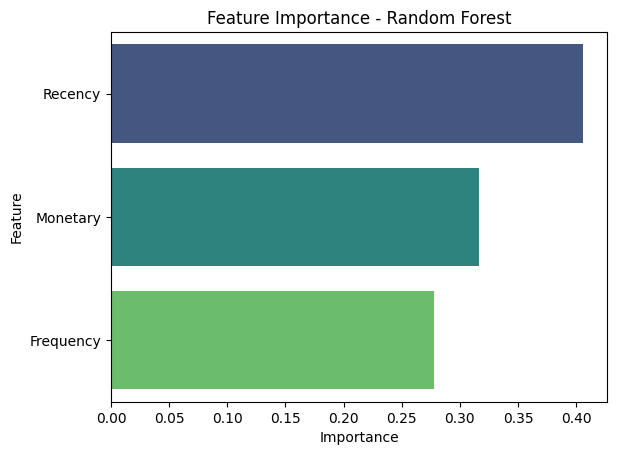

In [ ]:
importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    palette='viridis'
)

plt.title("Feature Importance - Random Forest")
plt.show()

The results show that Monetary value has the highest importance, followed by Frequency and Recency.

This indicates that total spending is the strongest driver of customer segment classification,
which aligns with business expectations that high-spending customers form distinct segments.

In [ ]:
#Predicting a cluster with unknown data
new_data = [[310,17,394]]
predicted_cluster = rf.predict(new_data)
print("Predicted Cluster:", predicted_cluster[0])

Predicted Cluster: 2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Saving the best model

In [ ]:
joblib.dump(rf, "final_random_forest_model.pkl")

['final_random_forest_model.pkl']

In [ ]:
rfm_model.head()

,Recency,Frequency,Monetary,KMeans_Cluster
CustomerID,,,,
12346,326,1,77183.60,2
12347,2,7,4310.00,1
12348,75,4,1797.24,2
12349,19,1,1757.55,0
12350,310,1,334.40,3


In [ ]:
rfm_dashboard = rfm_model.reset_index()

cluster_labels = {
    0: "New Customers",
    1: "VIP Customers",
    2: "Loyal Customers",
    3: "At-Risk Customers"
}

rfm_dashboard["Segment"] = rfm_dashboard["KMeans_Cluster"].map(cluster_labels)

rfm_dashboard.head()

,CustomerID,Recency,Frequency,Monetary,KMeans_Cluster,Segment
0,12346,326,1,77183.60,2,Loyal Customers
1,12347,2,7,4310.00,1,VIP Customers
2,12348,75,4,1797.24,2,Loyal Customers
3,12349,19,1,1757.55,0,New Customers
4,12350,310,1,334.40,3,At-Risk Customers


In [ ]:
rfm_dashboard.to_csv("rfm_dashboard_dataset.csv", index=False)

In [ ]:
original_df = df.copy()
original_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12


In [ ]:
original_df.to_csv("original_dataset.csv", index=False)

**Final Conclusion**


**1. Dataset and Preprocessing:**  
- The transactional dataset contained 541,909 records.  
- Data cleaning removed missing CustomerIDs, negative quantities, and canceled invoices.  
- Outliers in RFM features were not removed; instead, a log transformation was applied to reduce skewness while preserving high-value customers.

**2. RFM Feature Engineering:**  
- Recency, Frequency, and Monetary features were computed for each customer.  
- Histograms and distribution analysis revealed right-skewed behavior, typical of e-commerce platforms.

**3. Customer Segmentation (Clustering):**  
- Multiple clustering algorithms were compared (KMeans, Hierarchical, DBSCAN).  
- KMeans with 4 clusters provided the best silhouette score and interpretable segments:
    - **VIP / Best Customers:** Very recent, very high frequency & monetary  
    - **Loyal Customers:** Moderate recency, frequency, and monetary  
    - **New Customers:** Recent but low frequency & monetary  
    - **At-Risk Customers:** Long recency, low frequency & monetary  

**4. Prediction Models:**  
- Logistic Regression, Decision Tree, and Random Forest were trained to predict KMeans segments.  
- **Random Forest achieved the highest accuracy (98.4%)** and was chosen as the final model.  
- Feature importance showed that **Monetary** is the strongest driver of segment classification, followed by Frequency and Recency.

**5. Business Insights:**  
- VIP customers contribute disproportionately to revenue despite being a smaller segment.  
- At-Risk customers are the largest group but contribute minimal revenue, representing opportunities for re-engagement campaigns.  
- New customers need nurturing to convert them into loyal or VIP customers.